In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [3]:
# Load the dataset
df = pd.read_csv("Netflix_Life_Impact_Dataset_(NLID)[1].csv")

# Preview dataset structure
display(df.head().T)  
print(df.info())  # Check data types

,0,1,2,3,4
Movie Title,The Pursuit of Happyness,The Social Dilemma,Parasite,Paddington 2,Inception
Genre,Drama,Documentary,Thriller/Drama,Comedy/Family,Sci-Fi
Release Year,2006,2020,2019,2017,2010
Average Rating,9.1,8.2,9.3,8.8,9.0
Number of Reviews,42000,35000,50000,28000,45000
Review Highlights,"""Will Smith’s struggle hit hard. A must-watch!...","""Eye-opening about tech addiction."" / ""Some cl...","""Masterpiece on class inequality."" / ""Too dark...","""Pure joy! Teaches kindness effortlessly."" / ""...","""Mind-bending brilliance."" / ""Confusing plot."""
Minute of Life-Changing Insight,78:15 – Chris gets the job,12:40 – Algorithm manipulation,1:12:00 – The flood scene,33:10 – Paddington’s jail speech,1:05:22 – Cobb’s totem scene
How Discovered,Friend suggested,Social media,Netflix recommendation,Friend suggested,Social media
Meaningful Advice Taken,Persistence pays off.,Limit screen time for mental health.,Privilege isn’t always visible.,Always choose kindness.,Reality is subjective.
Suggested to Friends/Family (Y/N %),92% Y,88% Y,85% Y,95% Y,80% Y


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Movie Title                          82 non-null     object 
 1   Genre                                82 non-null     object 
 2   Release Year                         82 non-null     int64  
 3   Average Rating                       82 non-null     float64
 4   Number of Reviews                    82 non-null     int64  
 5   Review Highlights                    82 non-null     object 
 6   Minute of Life-Changing Insight      82 non-null     object 
 7   How Discovered                       82 non-null     object 
 8   Meaningful Advice Taken              82 non-null     object 
 9   Suggested to Friends/Family (Y/N %)  82 non-null     object 
dtypes: float64(1), int64(2), object(7)
memory usage: 6.5+ KB
None


In [4]:
# Convert column to string first to ensure processing compatibility
df["Minute of Life-Changing Insight"] = df["Minute of Life-Changing Insight"].astype(str)

# Extract numeric minutes from timestamps
df["Minute of Life-Changing Insight"] = np.array([
    int(s.split(":")[0]) if ":" in s else np.nan for s in df["Minute of Life-Changing Insight"]
])

# Drop non-numeric columns that aren't useful for prediction
df = df.drop(columns=[
    "Movie Title", "Review Highlights", "Meaningful Advice Taken", "Suggested to Friends/Family (Y/N %)"
])

In [5]:
scaler = StandardScaler()
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [6]:
X_reg = df.drop(columns=["Minute of Life-Changing Insight"])  # Features
y_reg = df["Minute of Life-Changing Insight"]  # Target

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [13]:
X_train_reg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65 entries, 62 to 51
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Genre              65 non-null     object 
 1   Release Year       65 non-null     float64
 2   Average Rating     65 non-null     float64
 3   Number of Reviews  65 non-null     float64
 4   How Discovered     65 non-null     object 
dtypes: float64(3), object(2)
memory usage: 3.0+ KB


In [11]:
X_test_reg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17 entries, 30 to 75
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Genre              17 non-null     object 
 1   Release Year       17 non-null     float64
 2   Average Rating     17 non-null     float64
 3   Number of Reviews  17 non-null     float64
 4   How Discovered     17 non-null     object 
dtypes: float64(3), object(2)
memory usage: 816.0+ bytes


In [9]:
y_train_reg

62    50
56     1
40     1
9      1
78     1
      ..
20     1
60    55
71    45
14     1
51     1
Name: Minute of Life-Changing Insight, Length: 65, dtype: int32

In [10]:
 y_test_reg

30     1
0     78
22     1
31     1
18     1
28     1
10     1
53    55
4      1
12     1
49    45
33     1
68    55
35     1
69     1
45     1
75     1
Name: Minute of Life-Changing Insight, dtype: int32

In [23]:
X_reg = pd.get_dummies(df.drop(columns=["Minute of Life-Changing Insight"]), drop_first=True)
X_reg1= X_reg.astype(float)
X_reg1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 36 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Release Year                            82 non-null     float64
 1   Average Rating                          82 non-null     float64
 2   Number of Reviews                       82 non-null     float64
 3   Genre_Adventure                         82 non-null     float64
 4   Genre_Animation                         82 non-null     float64
 5   Genre_Comedy                            82 non-null     float64
 6   Genre_Comedy/Crime                      82 non-null     float64
 7   Genre_Comedy/Drama                      82 non-null     float64
 8   Genre_Comedy/Family                     82 non-null     float64
 9   Genre_Crime/Drama                       82 non-null     float64
 10  Genre_Documentary                       82 non-null     float64


In [25]:
X_reg = df.drop(columns=["Minute of Life-Changing Insight"])  # Features
y_reg = df["Minute of Life-Changing Insight"]  # Target

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg1, y_reg, test_size=0.2, random_state=42)

In [28]:
xgb_reg = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_reg.fit(X_train_reg, y_train_reg)

y_pred_xgb = xgb_reg.predict(X_test_reg)

In [29]:
print(y_pred_xgb)

[ 8.354674   30.451868    0.3162313  16.300554    0.85301894  6.7929106
  2.460269    0.35616115 24.510746   26.093105    4.7257867   1.4610621
 29.71805     2.6205287  37.929836   -0.8528998  -2.045071  ]


In [30]:
rmse_xgb = mean_squared_error(y_test_reg, y_pred_xgb, squared=False)
r2_xgb = r2_score(y_test_reg, y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb}")
print(f"XGBoost R² Score: {r2_xgb}")

XGBoost RMSE: 24.726881147427964
XGBoost R² Score: 0.020553529262542725


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


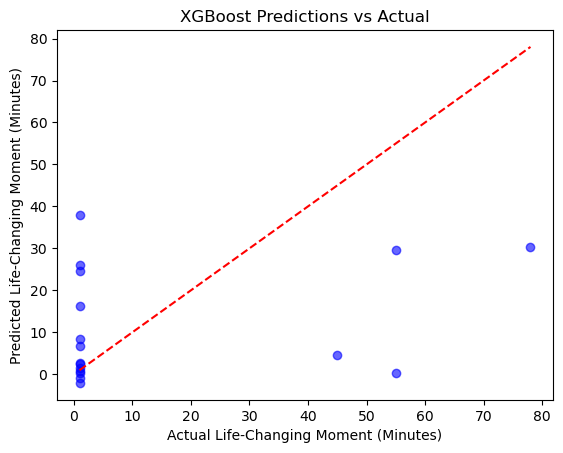

In [31]:
plt.scatter(y_test_reg, y_pred_xgb, alpha=0.6, color="blue")
plt.plot([min(y_test_reg), max(y_test_reg)], [min(y_test_reg), max(y_test_reg)], '--', color="red")  # Ideal prediction line
plt.xlabel("Actual Life-Changing Moment (Minutes)")
plt.ylabel("Predicted Life-Changing Moment (Minutes)")
plt.title("XGBoost Predictions vs Actual")
plt.show()